# Problem 16: Rectified Flow on MNIST Generation (30 pts)

This notebook trains and evaluates a Rectified Flow model on the MNIST dataset.

**Part 1 (10 pts):** Train the model, record the training loss curve, and visualize generated samples at different training stages.

**Part 2 (10 pts):** Analyze the effect of sampling steps (`num_steps`) on generation quality.

**Part 3 (10 pts):** Explore conditional generation and Classifier-Free Guidance (CFG).

In [2]:
!git clone https://github.com/aldookware/rectified-flow.git
%cd rectified-flow/

Cloning into 'rectified-flow'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 83 (delta 9), reused 81 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 10.81 MiB | 16.87 MiB/s, done.
Resolving deltas: 100% (9/9), done.
/content/rectified-flow


In [4]:
import math
import numpy as np
import torch
import torch.utils.checkpoint
import torchvision
import matplotlib.pyplot as plt

from torchvision import transforms
from tqdm.auto import tqdm

from rectified_flow.rectified_flow import RectifiedFlow
from rectified_flow.utils import match_dim_with_data
from rectified_flow.utils import plot_cifar_results

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
print(f"Using device: {device}")

Using device: cuda


## Load dataset

In [5]:
batch_size = 512

transform_list = [
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
]
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transforms.Compose(transform_list)
)

train_dataloader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False,
)

batch = next(iter(train_dataloader))
print(batch[0].shape)  # torch.Size([256, 1, 28, 28])

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.22MB/s]


torch.Size([512, 1, 28, 28])


## Train Unconditional Generation

In [6]:
import copy
import os
import torch

class EMAModel:
    def __init__(
        self,
        net: torch.nn.Module,
        ema_halflife_kimg: float = 2000.0,
        ema_rampup_ratio: float = 0.05,
    ):
        self.net = net
        self.ema = copy.deepcopy(net).eval().float()
        for param in self.ema.parameters():
            param.requires_grad_(False)
        self.ema_halflife_kimg = ema_halflife_kimg
        self.ema_rampup_ratio = ema_rampup_ratio

    @torch.no_grad()
    def update(self, cur_nimg: int, batch_size: int):
        """
        Update EMA parameters using a half-life strategy.

        Args:
            cur_nimg (int): The current number of images (could be total images processed so far).
            batch_size (int): The global batch size.
        """
        ema_halflife_nimg = self.ema_halflife_kimg * 1000

        if self.ema_rampup_ratio is not None:
            ema_halflife_nimg = min(ema_halflife_nimg, cur_nimg * self.ema_rampup_ratio)

        beta = 0.5 ** (batch_size / max(ema_halflife_nimg, 1e-8))

        for p_ema, p_net in zip(self.ema.parameters(), self.net.parameters()):
            p_ema.copy_((p_net.float()).lerp(p_ema, beta))

    def apply_shadow(self):
        """
        Copy EMA parameters back to the original `net`.
        """
        for p_net, p_ema in zip(self.net.parameters(), self.ema.parameters()):
            p_net.data.copy_(p_ema.data.to(p_net.dtype))

    def save_pretrained(self, save_directory: str, filename: str = "unet"):
        """
        Save the EMA model parameters to a file.
        """
        if not os.path.exists(save_directory):
            os.makedirs(save_directory)
        state_dict_cpu = {k: v.cpu() for k, v in self.ema.state_dict().items()}
        output_model_file = os.path.join(save_directory, f"{filename}_ema.pt")
        torch.save(state_dict_cpu, output_model_file)
        print(f"EMA model weights saved to {output_model_file}")

    def load_pretrained(self, save_directory: str, filename: str = "unet"):
        """
        Load EMA model parameters from a file.
        """
        output_model_file = os.path.join(save_directory, f"{filename}_ema.pt")
        if os.path.exists(output_model_file):
            state_dict = torch.load(output_model_file, map_location="cpu")
            self.ema.load_state_dict(state_dict, strict=True)
            net_device = next(self.net.parameters()).device
            self.ema.to(device=net_device, dtype=torch.float32)
            print(f"EMA weights loaded from {output_model_file}")
        else:
            print(f"No EMA weights found at {output_model_file}")

In [7]:
from rectified_flow.models.unet import SongUNet, SongUNetConfig
config = SongUNetConfig(
    img_resolution = 28,
    in_channels = 1,                  # Number of color channels at input.
    out_channels = 1,                 # Number of color channels at output.
    label_dim = 0,                    # Number of class labels, 0 = unconditional.
    augment_dim = 0,                  # Augmentation label dimensionality, 0 = no augmentation.

    model_channels = 64,                # Base multiplier for the number of channels.
    channel_mult = [2, 2],              # Channel multipliers for each resolution.
    channel_mult_emb = 2,               # Multiplier for the dimensionality of the embedding vector.
    num_blocks = 2,                     # Number of residual blocks per resolution.
    attn_resolutions = [14],            # Resolutions at which to apply attention.
    dropout = 0.13,                     # Dropout probability of intermediate activations.
    label_dropout = 0.0,                # Dropout probability of class labels for classifier-free guidance.
    embedding_type = "positional",      # Timestep embedding type: 'positional' or 'fourier'.
    channel_mult_time = 1,              # Timestep embedding size: 1 for DDPM++, 2 for NCSN++.
    encoder_type = "standard",          # Encoder architecture: 'standard' or 'residual'.
    decoder_type = "standard",          # Decoder architecture: 'standard' or 'residual'.
    resample_filter = [1, 1]
)
flow_model = SongUNet(config)
data_shape = (1, 28, 28)
flow_model = flow_model.to(device)

print(f"Number of parameters in flow model: {sum(p.numel() for p in flow_model.parameters() if p.requires_grad):,}")

ema_flow = EMAModel(flow_model, ema_halflife_kimg=1.0, ema_rampup_ratio=0.05)

optimizer = torch.optim.AdamW(
    flow_model.parameters(),
    lr=5e-4, weight_decay=0.01,
    betas=(0.9, 0.95)
)

compiled_flow = torch.compile(flow_model, mode="reduce-overhead", fullgraph=False, dynamic=False)

compiled_flow.train()
optimizer.zero_grad()

Number of parameters in flow model: 5,631,873


In [8]:
epoch = 20
# If you have A100 GPU, can set epoch to 200
cur_nimg = 0

try:
    from tqdm.auto import tqdm
except Exception:
    from tqdm import tqdm

def safe_tqdm_write(msg: str):
    try:
        tqdm.write(msg)
    except Exception:
        print(msg)

zero_to_none = True
grad_clip_norm = None

global_step = 0
running_loss = None
smooth_alpha = 0.99

# --- P16.1: Track losses for plotting ---
epoch_losses = []

# test model
with torch.no_grad():
    batch = next(iter(train_dataloader))
    x_1, c = batch
    x_1 = x_1.to(device, non_blocking=True).reshape(x_1.shape[0], *data_shape)
    x_0 = torch.randn_like(x_1)
    t = torch.rand(x_1.shape[0], device=x_1.device)
    v_pred = flow_model(x_1, t)
    print(x_1.shape, x_0.shape, v_pred.shape)
    sq_err = (v_pred - (x_1 - x_0)).pow(2).sum(dim=1)
    loss = sq_err.mean()
    safe_tqdm_write(f"Initial test loss: {loss.item():.4f}")

torch.Size([512, 1, 28, 28]) torch.Size([512, 1, 28, 28]) torch.Size([512, 1, 28, 28])
Initial test loss: 1.9282


In [9]:
# --- P16.1: Snapshot epochs for visualizing samples at different stages ---
snapshot_epochs = {1, 5, 10, 15, 20}
snapshot_samples = {}  # epoch -> generated tensor

# Fixed noise for consistent comparisons across epochs
fixed_noise = torch.randn(100, *data_shape).to(device)

for ep in tqdm(range(epoch), desc="Epochs", position=0):
    compiled_flow.train()
    epoch_loss_sum = 0.0
    epoch_steps = 0
    pbar = tqdm(train_dataloader, desc=f"ep {ep+1}/{epoch}", leave=False, position=1)
    for step, batch in enumerate(pbar):
        optimizer.zero_grad(set_to_none=zero_to_none)

        x_1, c = batch
        x_1 = x_1.to(device, non_blocking=True).reshape(x_1.shape[0], *data_shape)
        x_0 = torch.randn_like(x_1)

        B = x_1.shape[0]
        t = torch.rand(B, device=x_1.device, dtype=x_1.dtype)
        t_b = t.view(B, 1, 1, 1)

        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            x_t = t_b * x_1 + (1 - t_b) * x_0
            dot_x_t = x_1 - x_0
            v_pred = compiled_flow(x_t, t)

        loss = torch.nn.functional.mse_loss(v_pred.float(), dot_x_t.float())

        loss.backward()
        optimizer.step()

        global_step += 1
        cur_nimg += B
        ema_flow.update(cur_nimg=cur_nimg, batch_size=B)

        loss_val = float(loss.detach().item())
        epoch_loss_sum += loss_val
        epoch_steps += 1
        running_loss = loss_val if running_loss is None else (
            smooth_alpha * running_loss + (1 - smooth_alpha) * loss_val
        )

        pbar.set_postfix({
            "mse_loss": f"{loss_val:.4f}",
            "mse_loss_ema": f"{running_loss:.4f}",
            "steps": global_step
        })

    avg_epoch_loss = epoch_loss_sum / max(epoch_steps, 1)
    epoch_losses.append(avg_epoch_loss)
    safe_tqdm_write(f"[epoch {ep+1}/{epoch}] steps={global_step:,} avg_loss={avg_epoch_loss:.4f} ema_loss={running_loss:.4f}")

    # --- P16.1: Generate samples at snapshot epochs ---
    if (ep + 1) in snapshot_epochs:
        flow_model.eval()
        with torch.inference_mode():
            x_t = fixed_noise.clone()
            N = 100
            for i in range(N):
                t_val = i / N
                t_b = t_val * torch.ones(x_t.shape[0], device=device, dtype=x_t.dtype)
                v_pred = flow_model(x_t, t_b)
                x_t = x_t + v_pred * (1. / N)
            snapshot_samples[ep + 1] = x_t.cpu()
        flow_model.train()

    if (ep + 1) % 10 == 0:
        flow_model.save_pretrained(f"./checkpoints/flow_mnist")
        ema_flow.save_pretrained(f"./checkpoints/flow_mnist")

print(f"Training done. Total steps: {global_step:,}, last loss: {loss_val:.4f}, EMA: {running_loss:.4f}")

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

ep 1/20:   0%|          | 0/118 [00:00<?, ?it/s]

W0419 01:00:23.428000 937 torch/_inductor/utils.py:1679] [0/0_1] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2900: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist

[epoch 1/20] steps=118 avg_loss=0.4222 ema_loss=0.8326


ep 2/20:   0%|          | 0/118 [00:00<?, ?it/s]

...

[epoch 7/20] steps=826 avg_loss=0.1833 ema_loss=0.1846


ep 8/20:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 8/20] steps=944 avg_loss=0.1816 ema_loss=0.1822


ep 9/20:   0%|          | 0/118 [00:00<?, ?it/s]

KeyboardInterrupt: 

### P16.1: Training Loss Curve

Plot the average MSE loss per epoch to show training convergence.

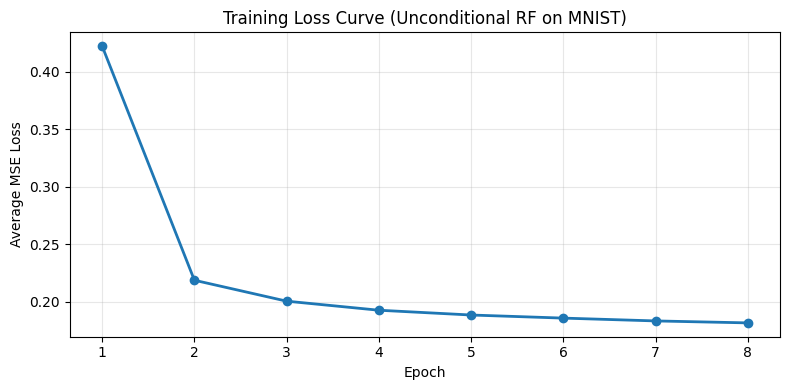

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Average MSE Loss")
plt.title("Training Loss Curve (Unconditional RF on MNIST)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### P16.1: Generated Samples at Different Training Stages

Visualize how sample quality improves as training progresses.

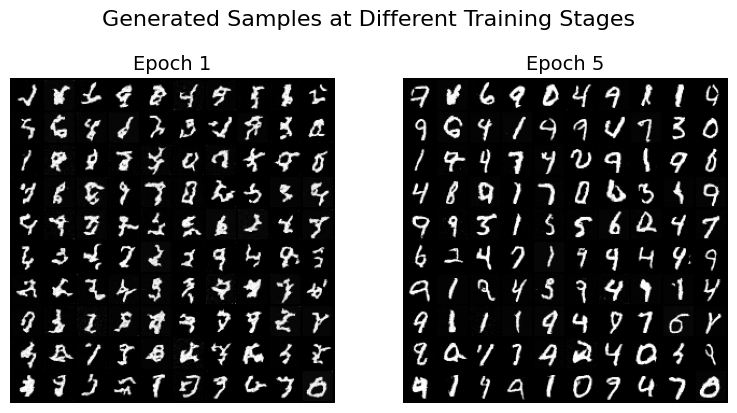

In [11]:
fig, axes = plt.subplots(1, len(snapshot_samples), figsize=(4 * len(snapshot_samples), 4))
if len(snapshot_samples) == 1:
    axes = [axes]

for ax, (ep_num, samples) in zip(axes, sorted(snapshot_samples.items())):
    # Show a 10x10 grid of generated digits
    grid = torchvision.utils.make_grid(samples[:100], nrow=10, normalize=True, value_range=(-1, 1))
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    ax.set_title(f"Epoch {ep_num}", fontsize=14)
    ax.axis('off')

fig.suptitle("Generated Samples at Different Training Stages", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
from rectified_flow.samplers import EulerSampler, SDESampler

ema_flow.apply_shadow()
model_inference = flow_model.eval()

rf_inference = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=model_inference,
    device=device,
)

euler_sampler = EulerSampler(rf_inference, num_steps=200)
sde_sampler = SDESampler(rf_inference, num_steps=200, noise_scale=5, noise_decay_rate=0.)

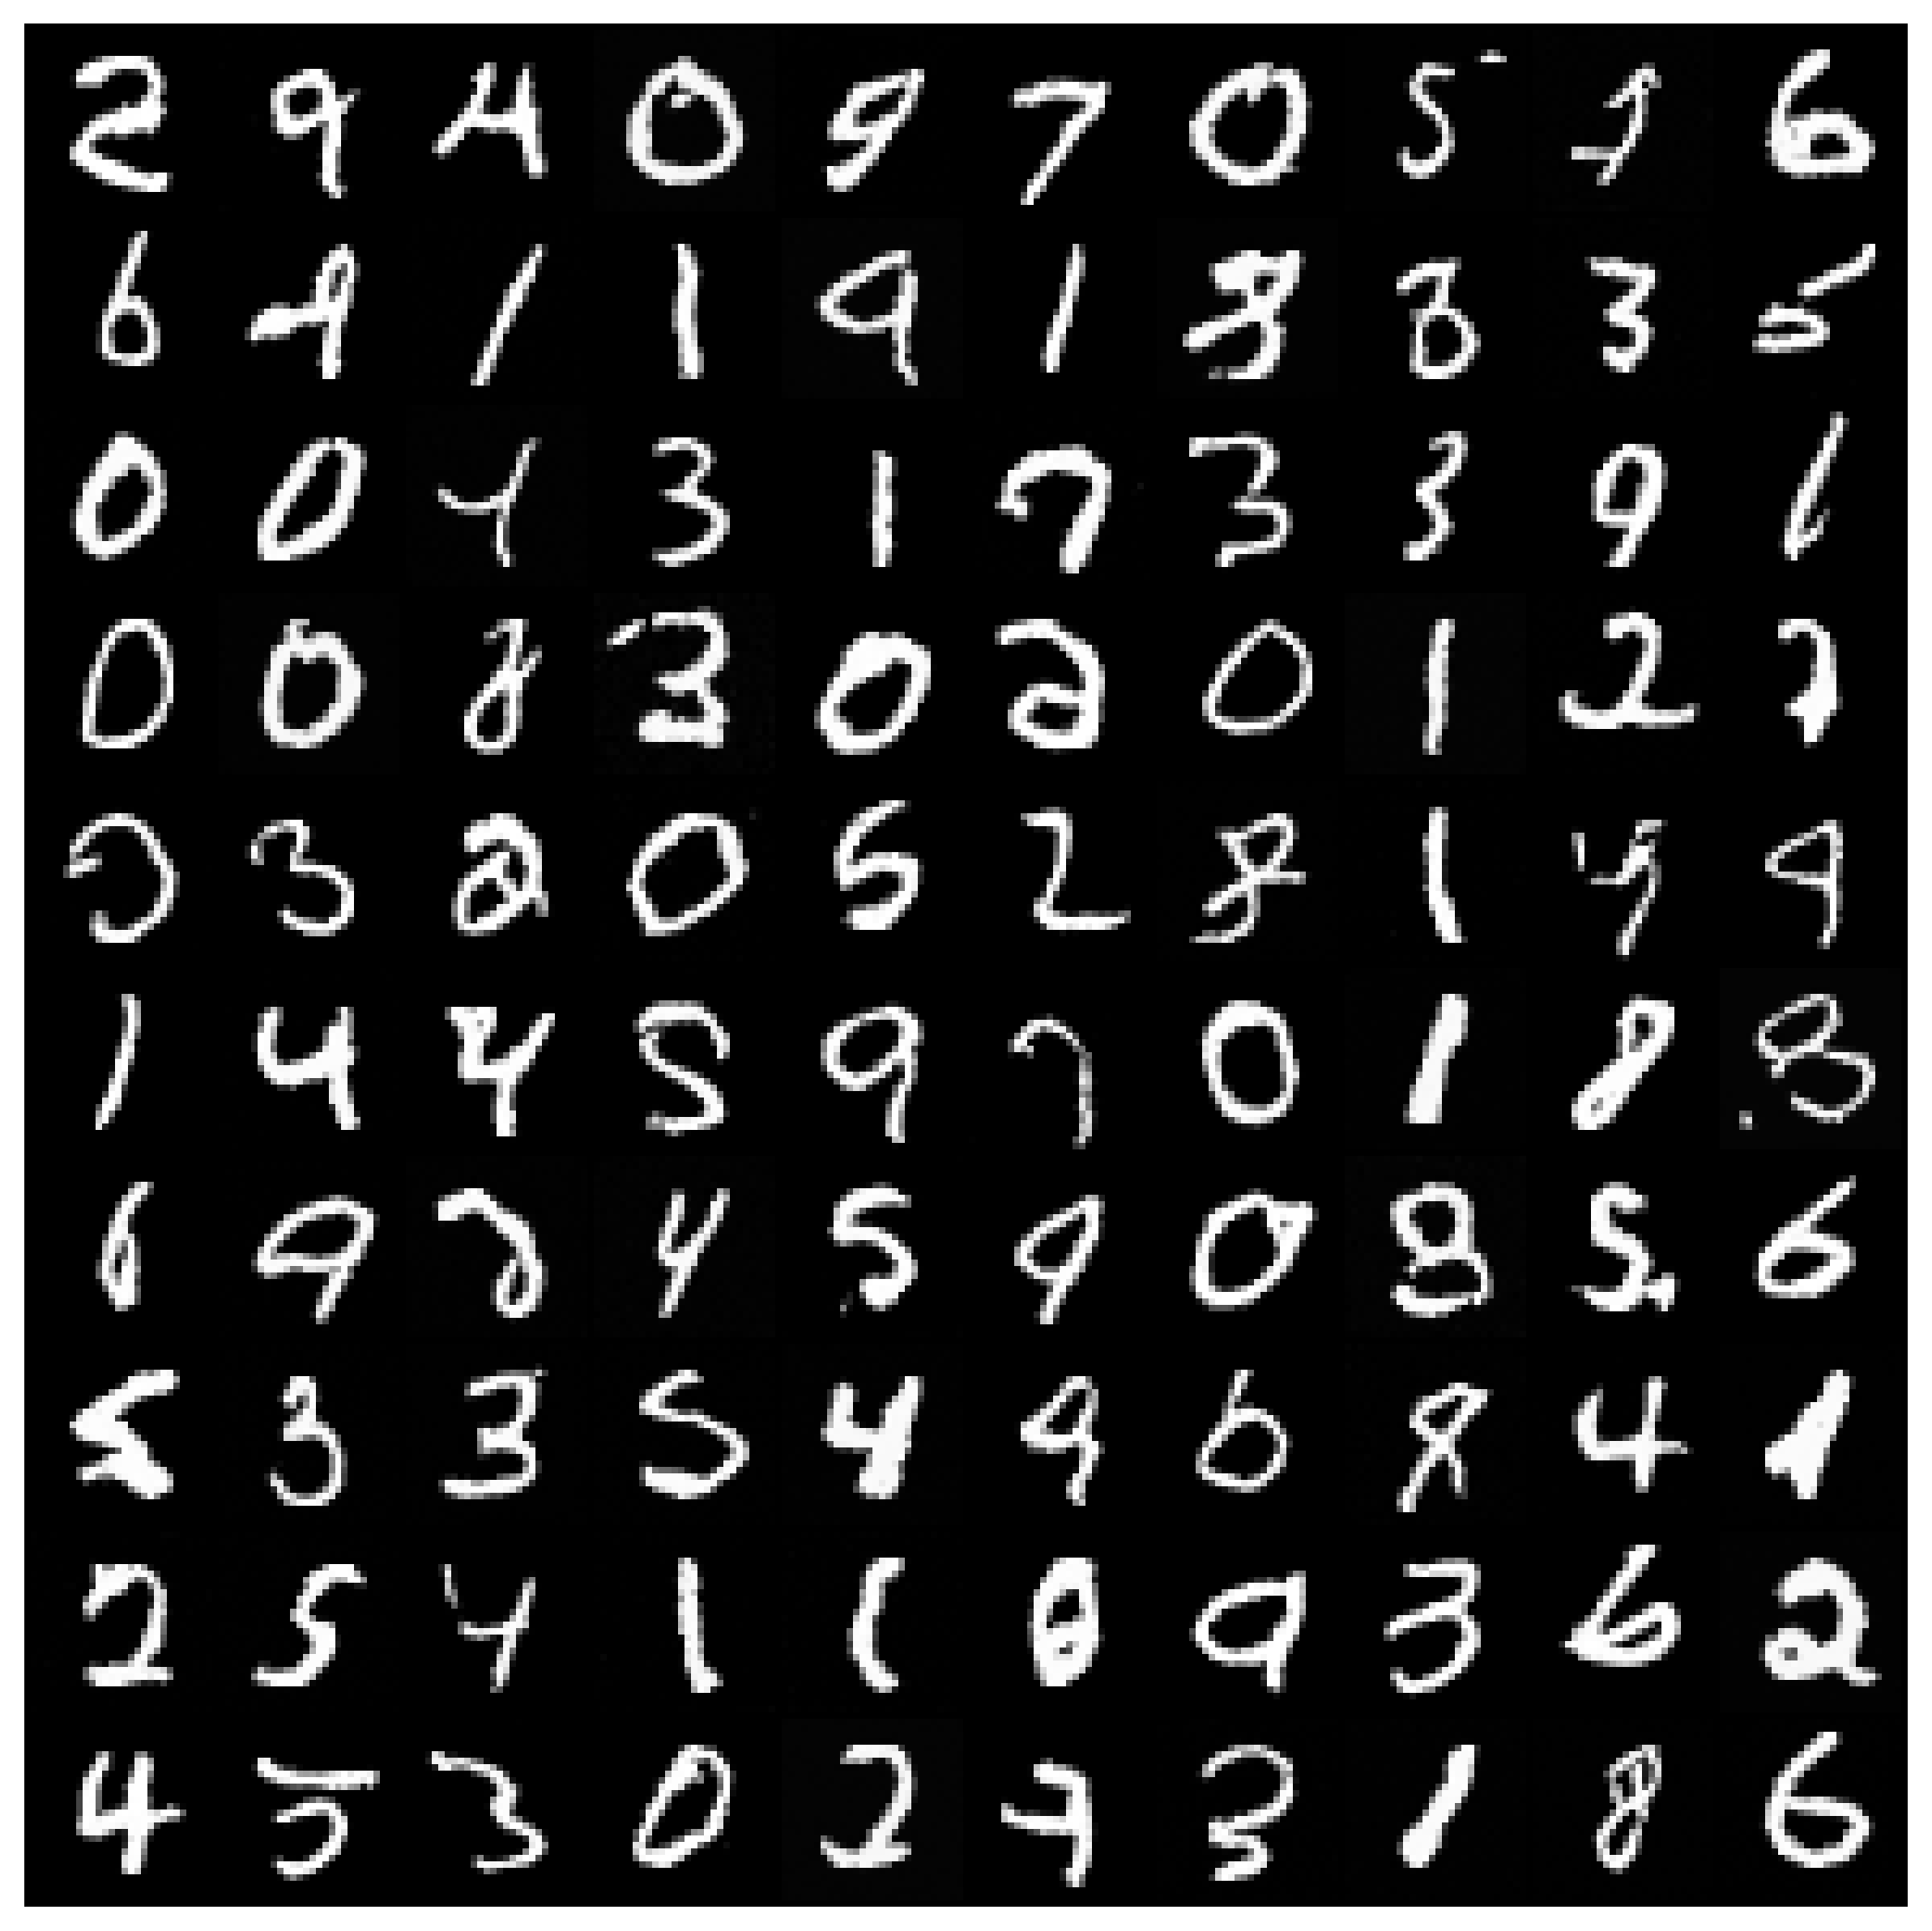

In [13]:
x_0 = torch.randn(100, *data_shape).to(device)

x_t = x_0.clone()

N = 100

# Implement Euler Sampler
with torch.inference_mode():
  for i in range(N):
      t = i / N
      t_b = t * torch.ones(x_0.shape[0], device=x_0.device, dtype=x_0.dtype)
      v_pred = flow_model(x_t, t_b)
      x_t = x_t + v_pred * (1. / N)

plot_cifar_results(x_t)


In [14]:
x_0 = torch.randn(30, *data_shape).to(device) * 0.5

x_1_euler = euler_sampler.sample_loop(x_0=x_0).trajectories[-1]
x_1_sde = sde_sampler.sample_loop(x_0=x_0).trajectories[-1]

print(x_1.shape)  # torch.Size([20, 1, 28, 28])

torch.Size([512, 1, 28, 28])


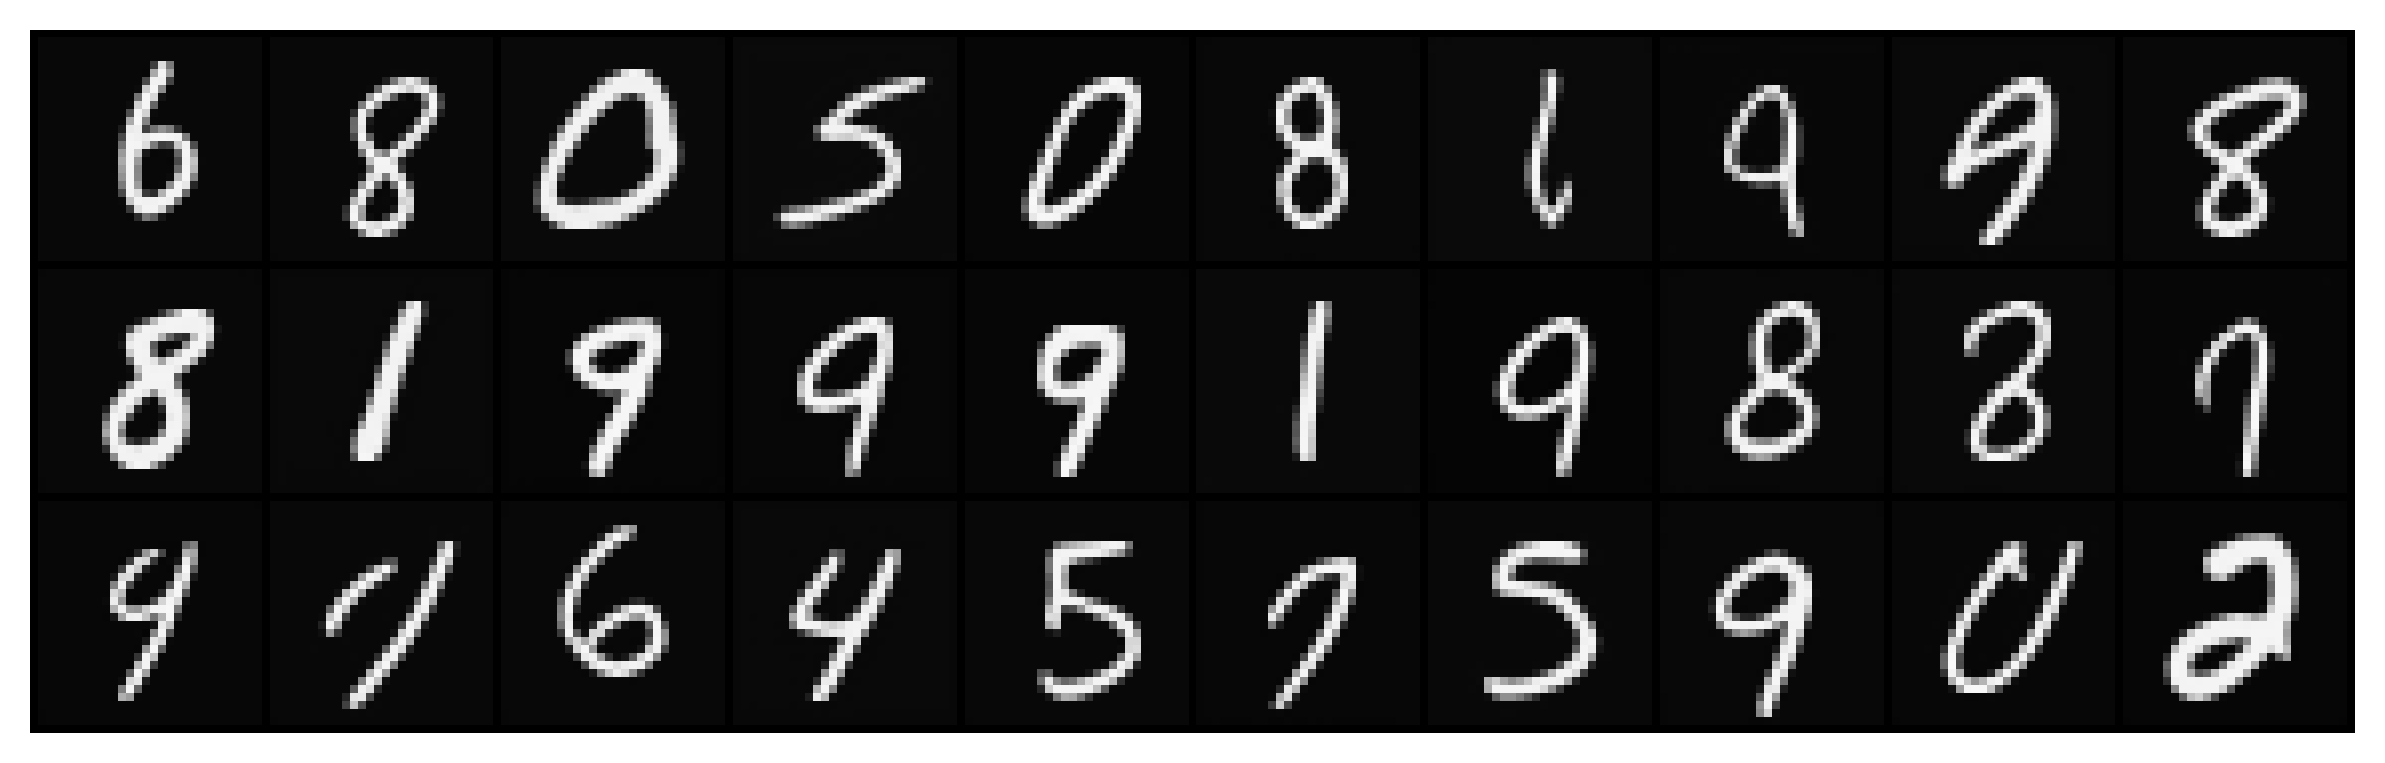

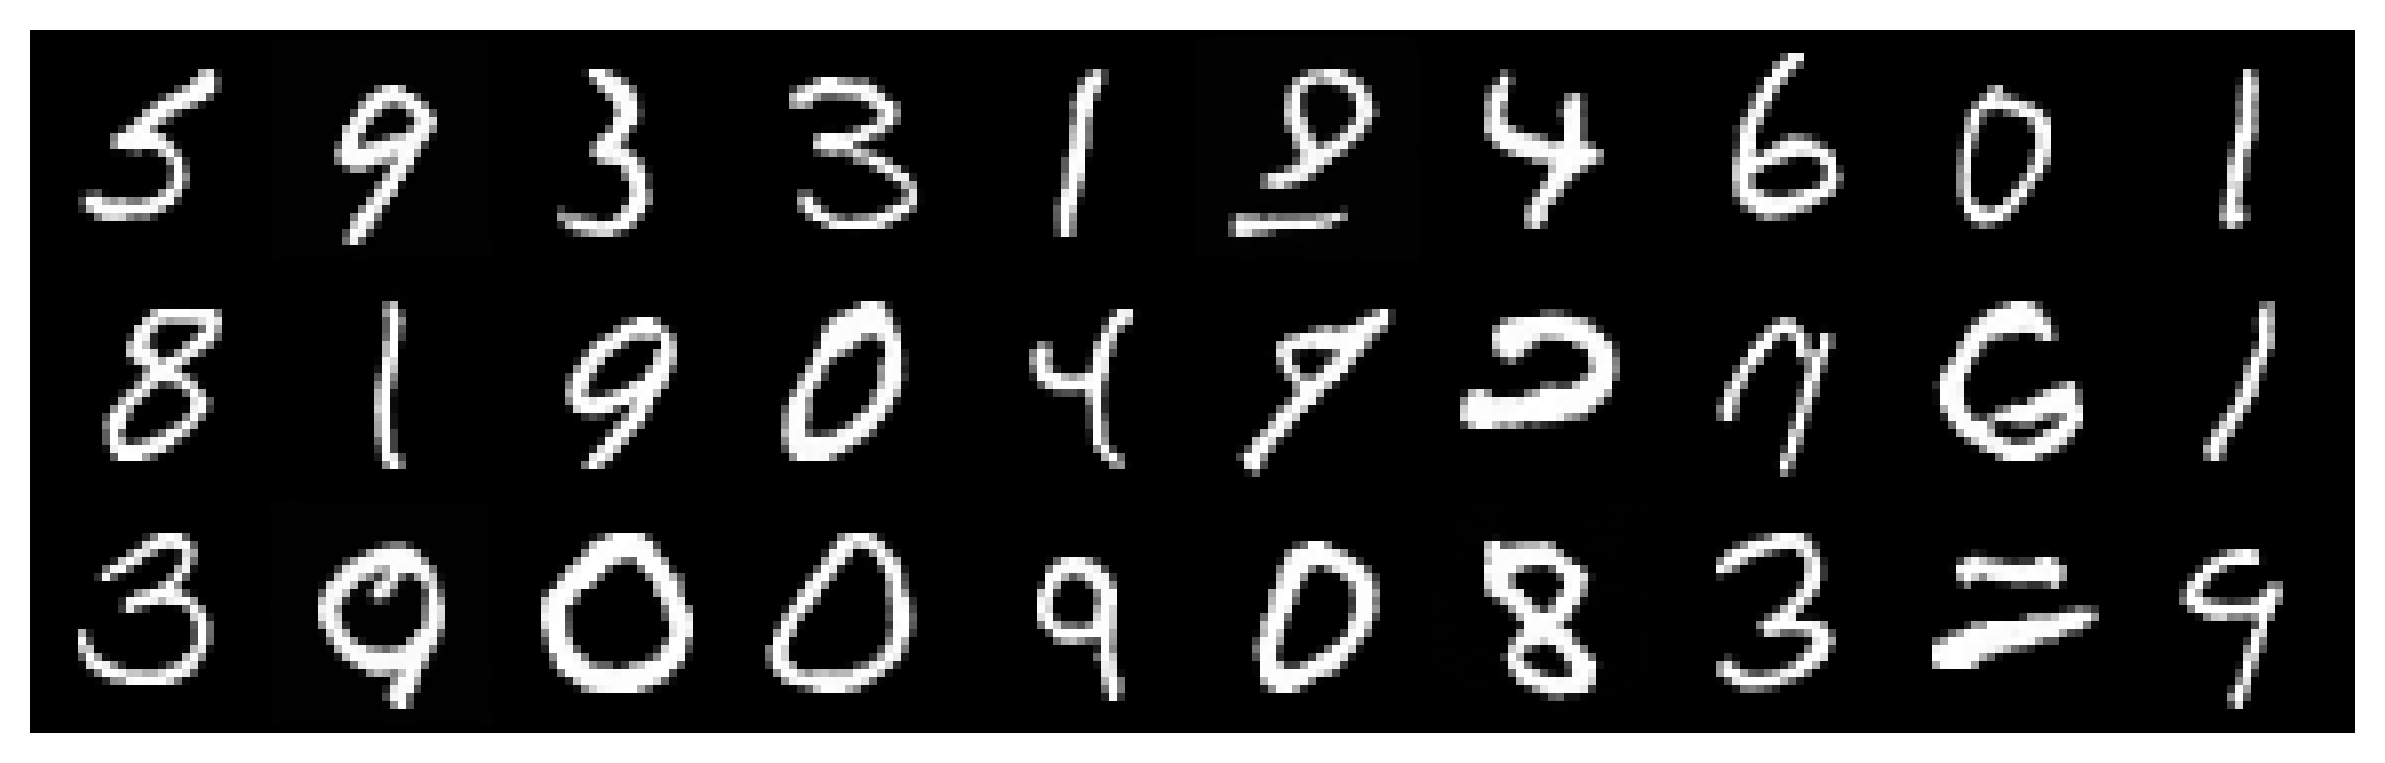

In [15]:
plot_cifar_results(x_1_euler)
plot_cifar_results(x_1_sde)

## Part 2 (10 pts): Effect of Sampling Steps

We vary `num_steps` from very few (2, 5, 10) to many (25, 50, 100) and compare the generated image quality. Fewer steps should produce blurrier, less consistent samples, while more steps yield sharper results.

In [16]:
from rectified_flow.samplers import EulerSampler

ema_flow.apply_shadow()
model_inference = flow_model.eval()

rf_inference = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=model_inference,
    device=device,
)

# Fixed noise for fair comparison across step counts
fixed_x0 = torch.randn(100, *data_shape).to(device)

step_counts = [2, 5, 10, 25, 50, 100]
step_results = {}

for n_steps in step_counts:
    sampler = EulerSampler(rf_inference, num_steps=n_steps)
    x_1 = sampler.sample_loop(x_0=fixed_x0.clone()).trajectories[-1]
    step_results[n_steps] = x_1.cpu()
    print(f"num_steps={n_steps:3d} done")

num_steps=  2 done
num_steps=  5 done
num_steps= 10 done
num_steps= 25 done
num_steps= 50 done
num_steps=100 done


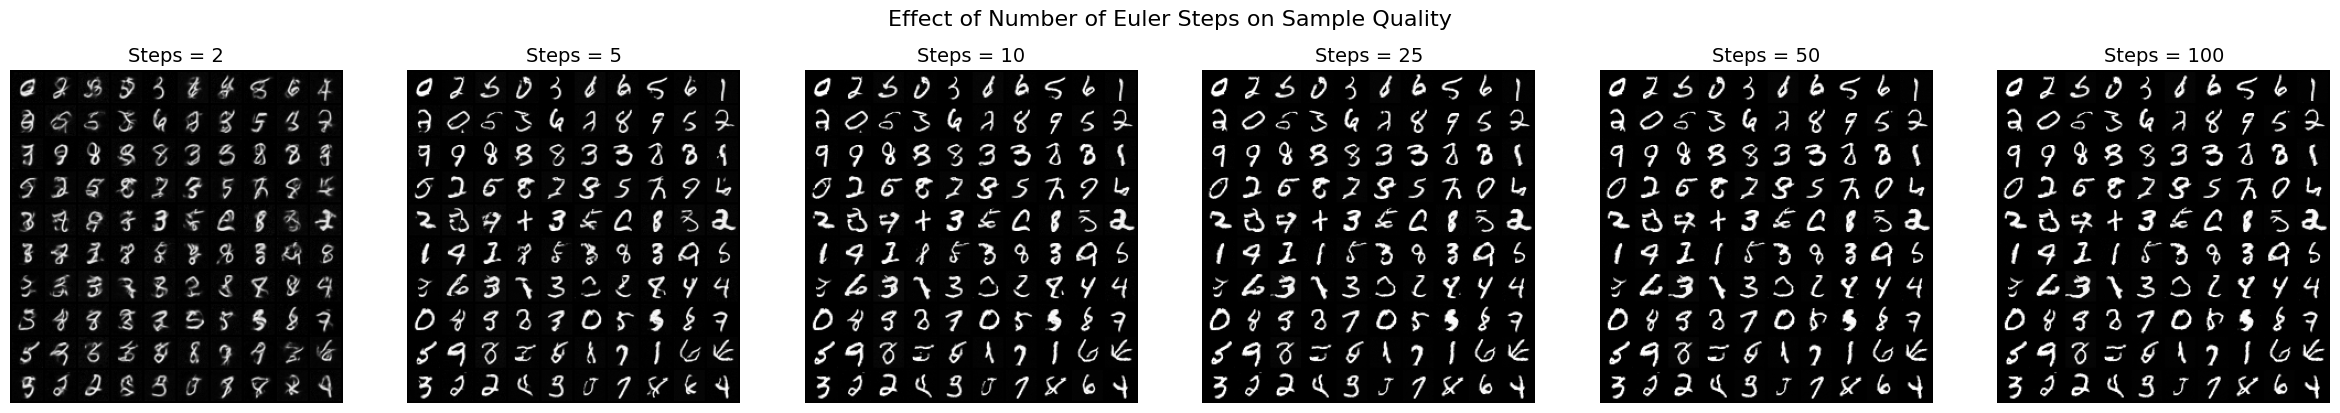

In [17]:
fig, axes = plt.subplots(1, len(step_counts), figsize=(4 * len(step_counts), 4))

for ax, n_steps in zip(axes, step_counts):
    samples = step_results[n_steps]
    grid = torchvision.utils.make_grid(samples[:100], nrow=10, normalize=True, value_range=(-1, 1))
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    ax.set_title(f"Steps = {n_steps}", fontsize=14)
    ax.axis('off')

fig.suptitle("Effect of Number of Euler Steps on Sample Quality", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Observations on Sampling Steps

**With very few steps (2-5):** Samples appear blurry and lack fine detail. The digits are often malformed because the Euler ODE solver takes overly large steps, accumulating significant discretization error.

**With moderate steps (10-25):** Digit shapes become recognizable and relatively sharp. Most digits are identifiable, though some fine details may still be missing.

**With many steps (50-100):** Samples are sharp and consistent. The marginal improvement beyond ~50 steps is minimal, indicating convergence of the ODE solver.

This demonstrates the key property of rectified flow: because the learned trajectories tend to be relatively straight, even moderate step counts (10-25) can produce reasonable results, unlike diffusion models that often require hundreds of steps.

## Train Conditional Generation

In [18]:
model_type = "unet"    # "mlp" or "unet" or "dit"

if model_type == "unet":
    from rectified_flow.models.unet import SongUNet, SongUNetConfig
    config = SongUNetConfig(
        img_resolution = 28,
        in_channels = 1,                  # Number of color channels at input.
        out_channels = 1,                 # Number of color channels at output.
        label_dim = 10,                   # 10 MNIST classes for conditional generation.
        augment_dim = 0,                  # Augmentation label dimensionality, 0 = no augmentation.

        model_channels = 64,                # Base multiplier for the number of channels.
        channel_mult = [2, 2],              # Channel multipliers for each resolution.
        channel_mult_emb = 2,               # Multiplier for the dimensionality of the embedding vector.
        num_blocks = 2,                     # Number of residual blocks per resolution.
        attn_resolutions = [14],            # Resolutions at which to apply attention.
        dropout = 0.13,                     # Dropout probability of intermediate activations.
        label_dropout = 0.1,                # Dropout probability of class labels for classifier-free guidance.
        embedding_type = "positional",      # Timestep embedding type: 'positional' or 'fourier'.
        channel_mult_time = 1,              # Timestep embedding size: 1 for DDPM++, 2 for NCSN++.
        encoder_type = "standard",          # Encoder architecture: 'standard' or 'residual'.
        decoder_type = "standard",          # Decoder architecture: 'standard' or 'residual'.
        resample_filter = [1, 1]
    )
    flow_model = SongUNet(config)
    data_shape = (1, 28, 28)
elif model_type == "dit":
    raise NotImplementedError
else:
    raise ValueError(f"Unknown model type: {model_type}")

flow_model = flow_model.to(device)

print(f"Number of parameters in flow model: {sum(p.numel() for p in flow_model.parameters() if p.requires_grad):,}")

ema_flow = EMAModel(flow_model, ema_halflife_kimg=1.0, ema_rampup_ratio=0.05)

optimizer = torch.optim.AdamW(
    flow_model.parameters(),
    lr=5e-4, weight_decay=0.01,
    betas=(0.9, 0.95)
)

compiled_flow = torch.compile(flow_model, mode="reduce-overhead", fullgraph=False, dynamic=False)

compiled_flow.train()
optimizer.zero_grad()

Number of parameters in flow model: 5,632,577


In [19]:
epoch = 200
cur_nimg = 0

rf_train = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=compiled_flow,
    train_time_distribution="uniform",
    device=device,
)

try:
    from tqdm.auto import tqdm
except Exception:
    from tqdm import tqdm

def safe_tqdm_write(msg: str):
    try:
        tqdm.write(msg)
    except Exception:
        print(msg)

zero_to_none = True
grad_clip_norm = None

global_step = 0
running_loss = None
smooth_alpha = 0.99

# test model
with torch.no_grad():
    batch = next(iter(train_dataloader))
    x_1, c = batch
    x_1 = x_1.to(device, non_blocking=True).reshape(x_1.shape[0], *data_shape)
    c = c.to(device, non_blocking=True)
    c_onehot = torch.nn.functional.one_hot(c, num_classes=10).float()
    x_0 = torch.randn_like(x_1)
    t = rf_train.sample_train_time(x_1.shape[0]).to(device, non_blocking=True)
    # print(x_1.shape, x_0.shape, c.shape, t.shape)
    v_pred = flow_model(x_1, t, c_onehot)
    sq_err = (v_pred - (x_1 - x_0)).pow(2).sum(dim=1)
    loss = sq_err.mean()
    safe_tqdm_write(f"Initial test loss: {loss.item():.4f}")

Initial test loss: 1.9277


In [20]:
cond_epoch_losses = []

for ep in tqdm(range(epoch), desc="Epochs", position=0):
    epoch_loss_sum = 0.0
    epoch_steps = 0
    pbar = tqdm(train_dataloader, desc=f"ep {ep+1}/{epoch}", leave=False, position=1)
    for step, batch in enumerate(pbar):
        optimizer.zero_grad(set_to_none=zero_to_none)

        x_1, c = batch
        c_onehot = torch.nn.functional.one_hot(c, num_classes=10).float()
        c_onehot = c_onehot.to(device, non_blocking=True)

        x_1 = x_1.to(device, non_blocking=True).reshape(x_1.shape[0], *data_shape)
        x_0 = torch.randn_like(x_1)
        t = rf_train.sample_train_time(x_1.shape[0]).to(device, non_blocking=True)

        # --- forward (bf16 autocast) ---
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            x_t, dot_x_t = rf_train.get_interpolation(x_0=x_0, x_1=x_1, t=t)
            v_pred = rf_train.get_velocity(x_t, t, class_labels=c_onehot)

        # --- pure MSE loss in fp32 for stability ---
        loss = torch.nn.functional.mse_loss(v_pred.float(), dot_x_t.float())
        mse_loss = float(loss.detach().item())

        loss.backward()

        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(rf_train.parameters(), grad_clip_norm)

        optimizer.step()

        global_step += 1
        cur_nimg += x_1.shape[0]
        ema_flow.update(cur_nimg=cur_nimg, batch_size=x_1.shape[0])

        loss_val = float(loss.detach().item())
        epoch_loss_sum += loss_val
        epoch_steps += 1
        running_loss = loss_val if running_loss is None else (
            smooth_alpha * running_loss + (1 - smooth_alpha) * mse_loss
        )

        pbar.set_postfix({
            "mse_loss": f"{mse_loss:.4f}",
            "mse_loss_ema": f"{running_loss:.4f}",
            "steps": global_step
        })

    avg_epoch_loss = epoch_loss_sum / max(epoch_steps, 1)
    cond_epoch_losses.append(avg_epoch_loss)
    safe_tqdm_write(
        f"[epoch {ep+1}/{epoch}] steps={global_step:,} "
        f"avg_loss={avg_epoch_loss:.4f}, mse_loss_ema={running_loss:.4f}"
    )

    if (ep + 1) % 10 == 0:
        flow_model.save_pretrained(f"./checkpoints/flow_mnist_unet_conditional")
        ema_flow.save_pretrained(f"./checkpoints/flow_mnist_unet_conditional")

print(f"Training done. Total steps: {global_step:,}, last loss: {loss_val:.4f}, EMA: {running_loss:.4f}")

Epochs:   0%|          | 0/200 [00:00<?, ?it/s]

ep 1/200:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 1/200] steps=118 avg_loss=0.4540, mse_loss_ema=0.8493


ep 2/200:   0%|          | 0/118 [00:00<?, ?it/s]

[epoch 2/200] steps=236 avg_loss=0.2117, mse_loss_ema=0.4038


ep 3/200:   0%|          | 0/118 [00:00<?, ?it/s]

KeyboardInterrupt: 

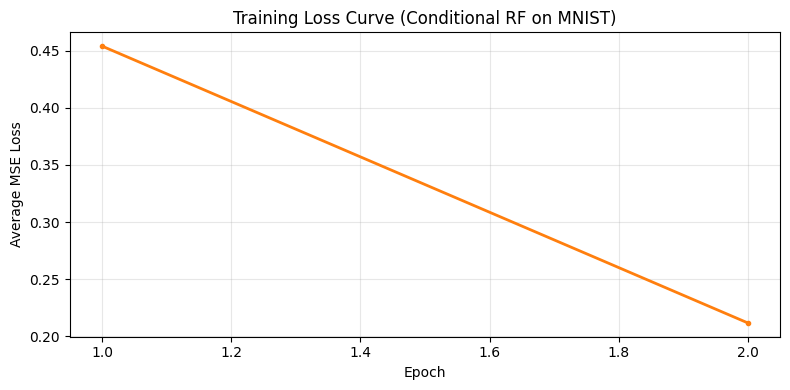

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cond_epoch_losses) + 1), cond_epoch_losses, marker='.', linewidth=2, color='tab:orange')
plt.xlabel("Epoch")
plt.ylabel("Average MSE Loss")
plt.title("Training Loss Curve (Conditional RF on MNIST)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Class Conditional Generation without CFG

In [22]:
from rectified_flow.samplers import EulerSampler, SDESampler

# flow_model = SongUNet.from_pretrained(f"./checkpoints/flow_mnist_unet_conditional", use_ema=False).to(device)

model_inference = flow_model.eval()

rf_inference = RectifiedFlow(
    data_shape=data_shape,
    velocity_field=model_inference,
    device=device,
)

# generate 100 samples for each class
class_labels = torch.arange(10, device=device)
class_labels = class_labels.repeat_interleave(10, dim=0)
class_onehot = torch.nn.functional.one_hot(class_labels, num_classes=10).float()

euler_sampler = EulerSampler(rf_inference, num_steps=50, num_samples=100)
sde_sampler = SDESampler(rf_inference, num_steps=50, noise_scale=50, noise_decay_rate=0., num_samples=100)

In [23]:
x_1_euler = euler_sampler.sample_loop(seed=33, class_labels=class_onehot).trajectories[-1]
x_1_sde = sde_sampler.sample_loop(seed=33, class_labels=class_onehot).trajectories[-1]

print(x_1_euler.shape)  # torch.Size([20, 1, 28, 28])

torch.Size([100, 1, 28, 28])


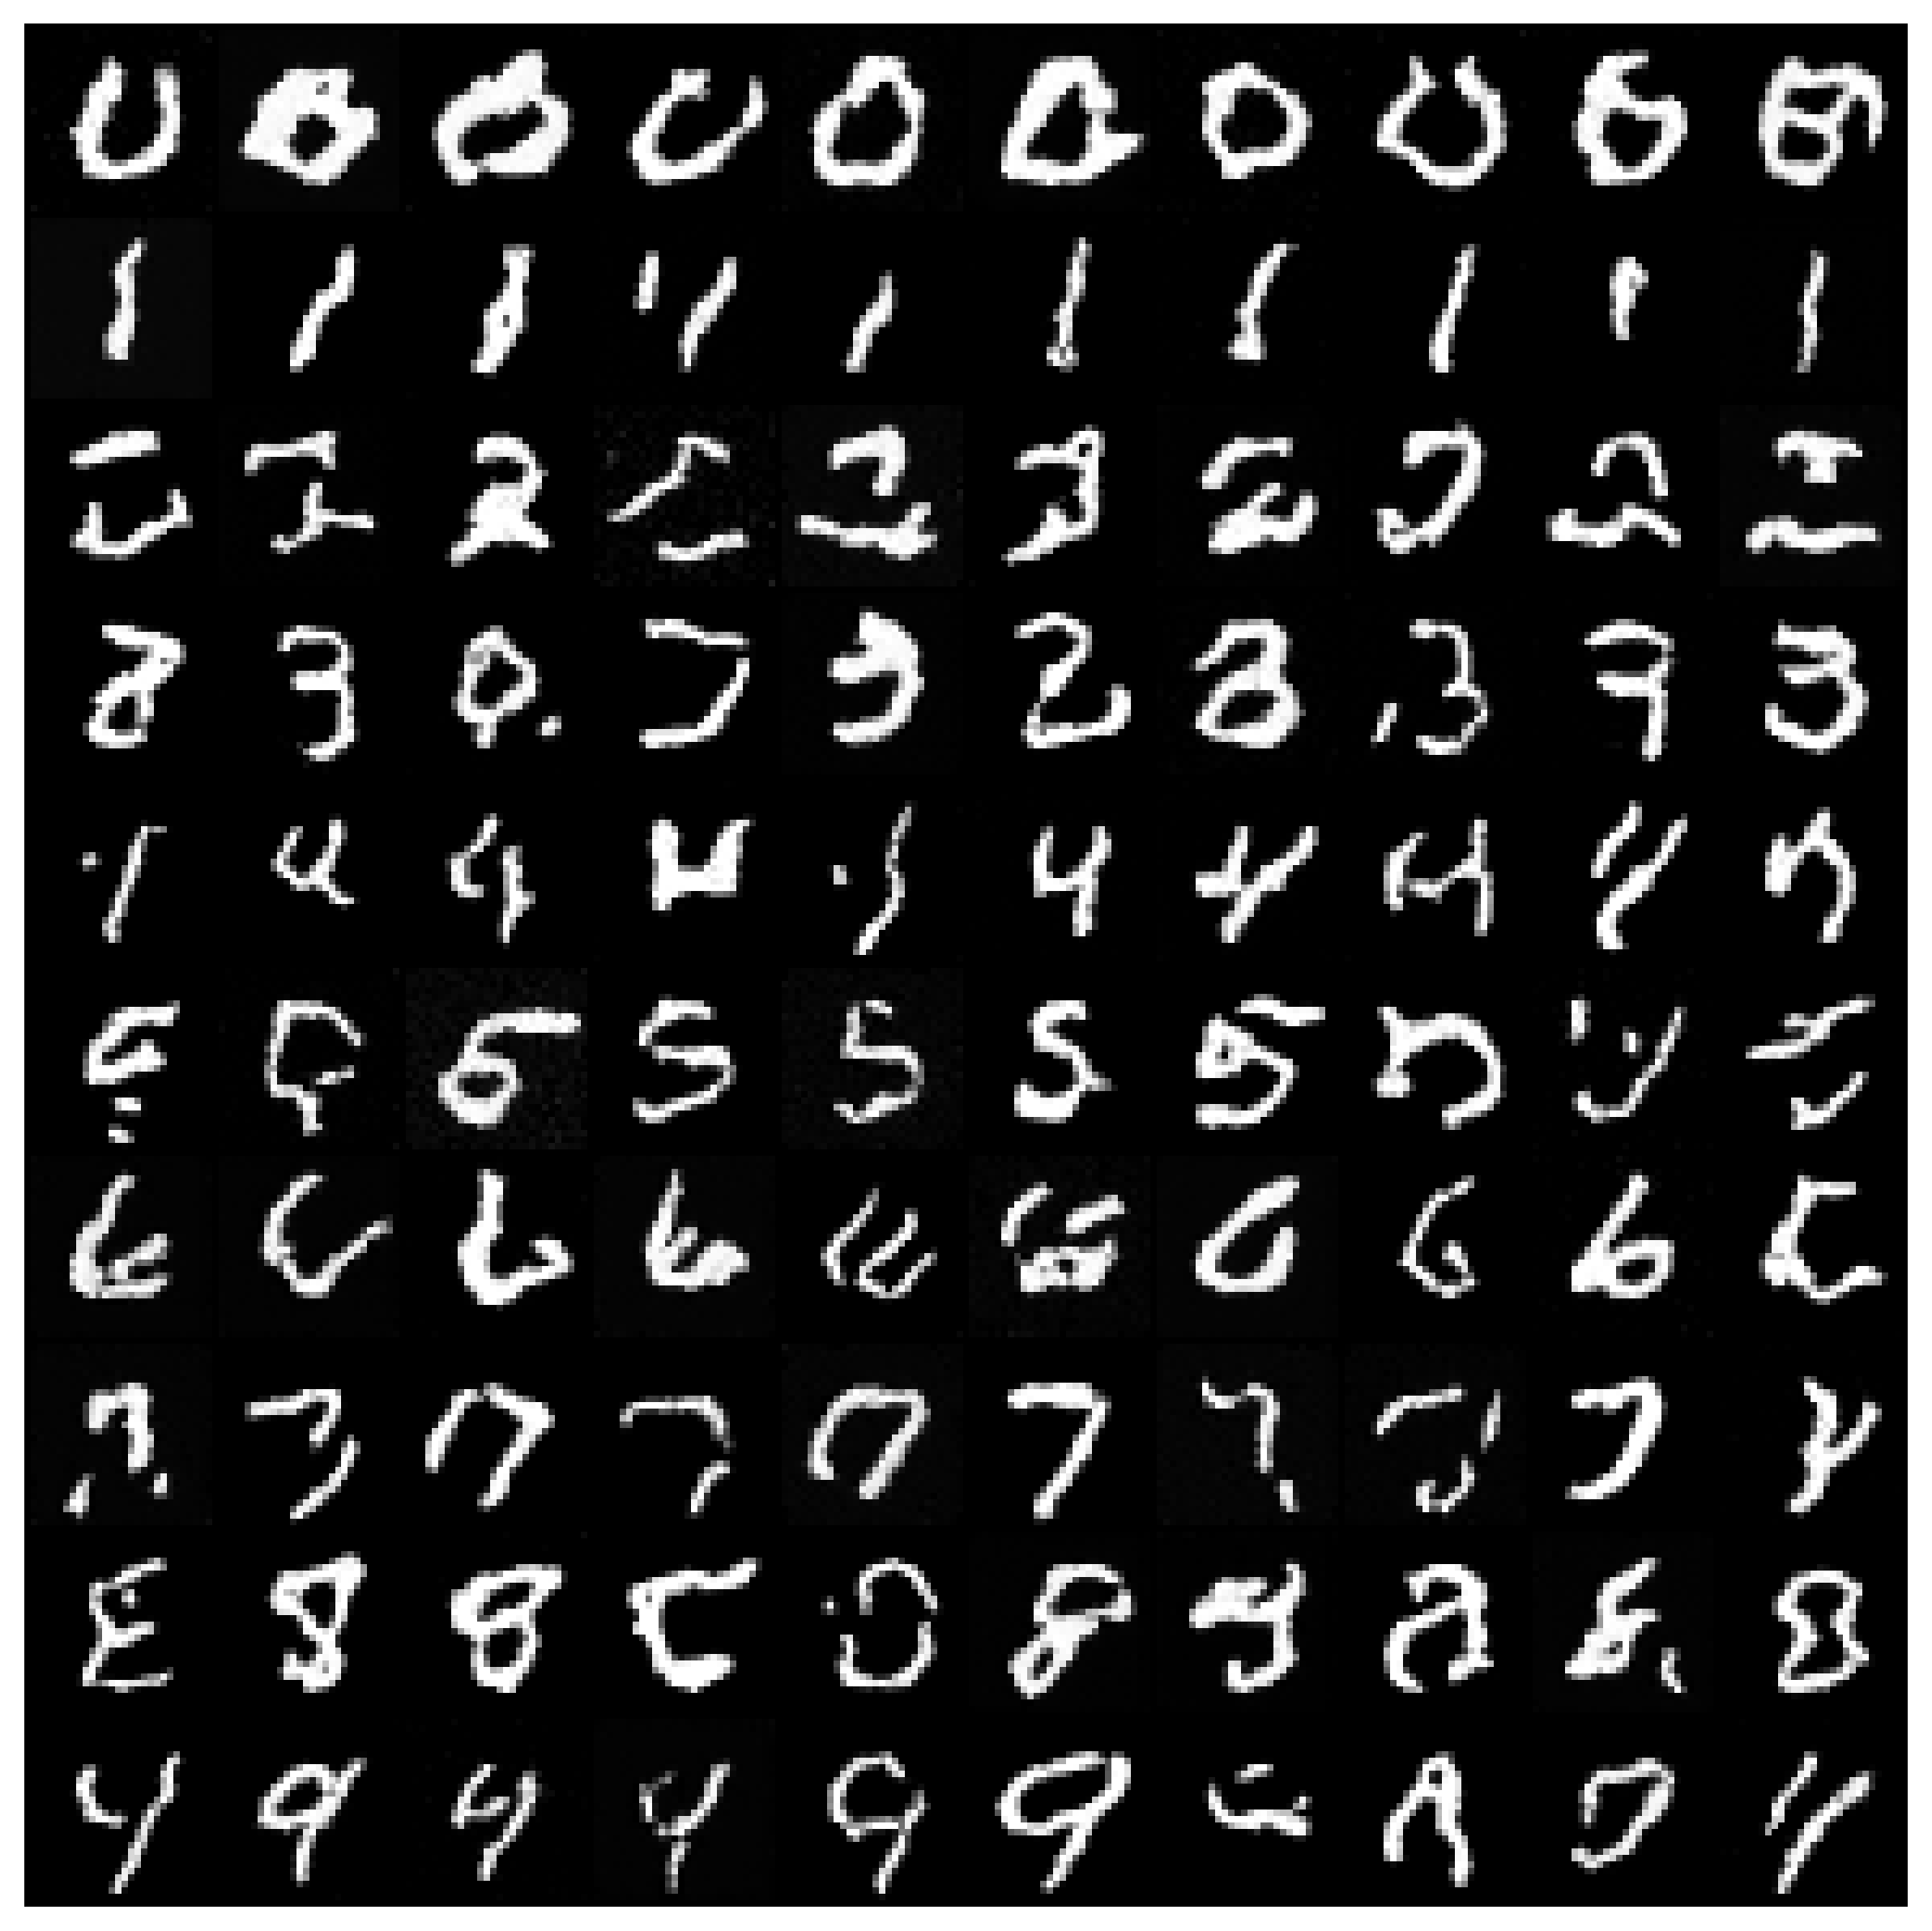

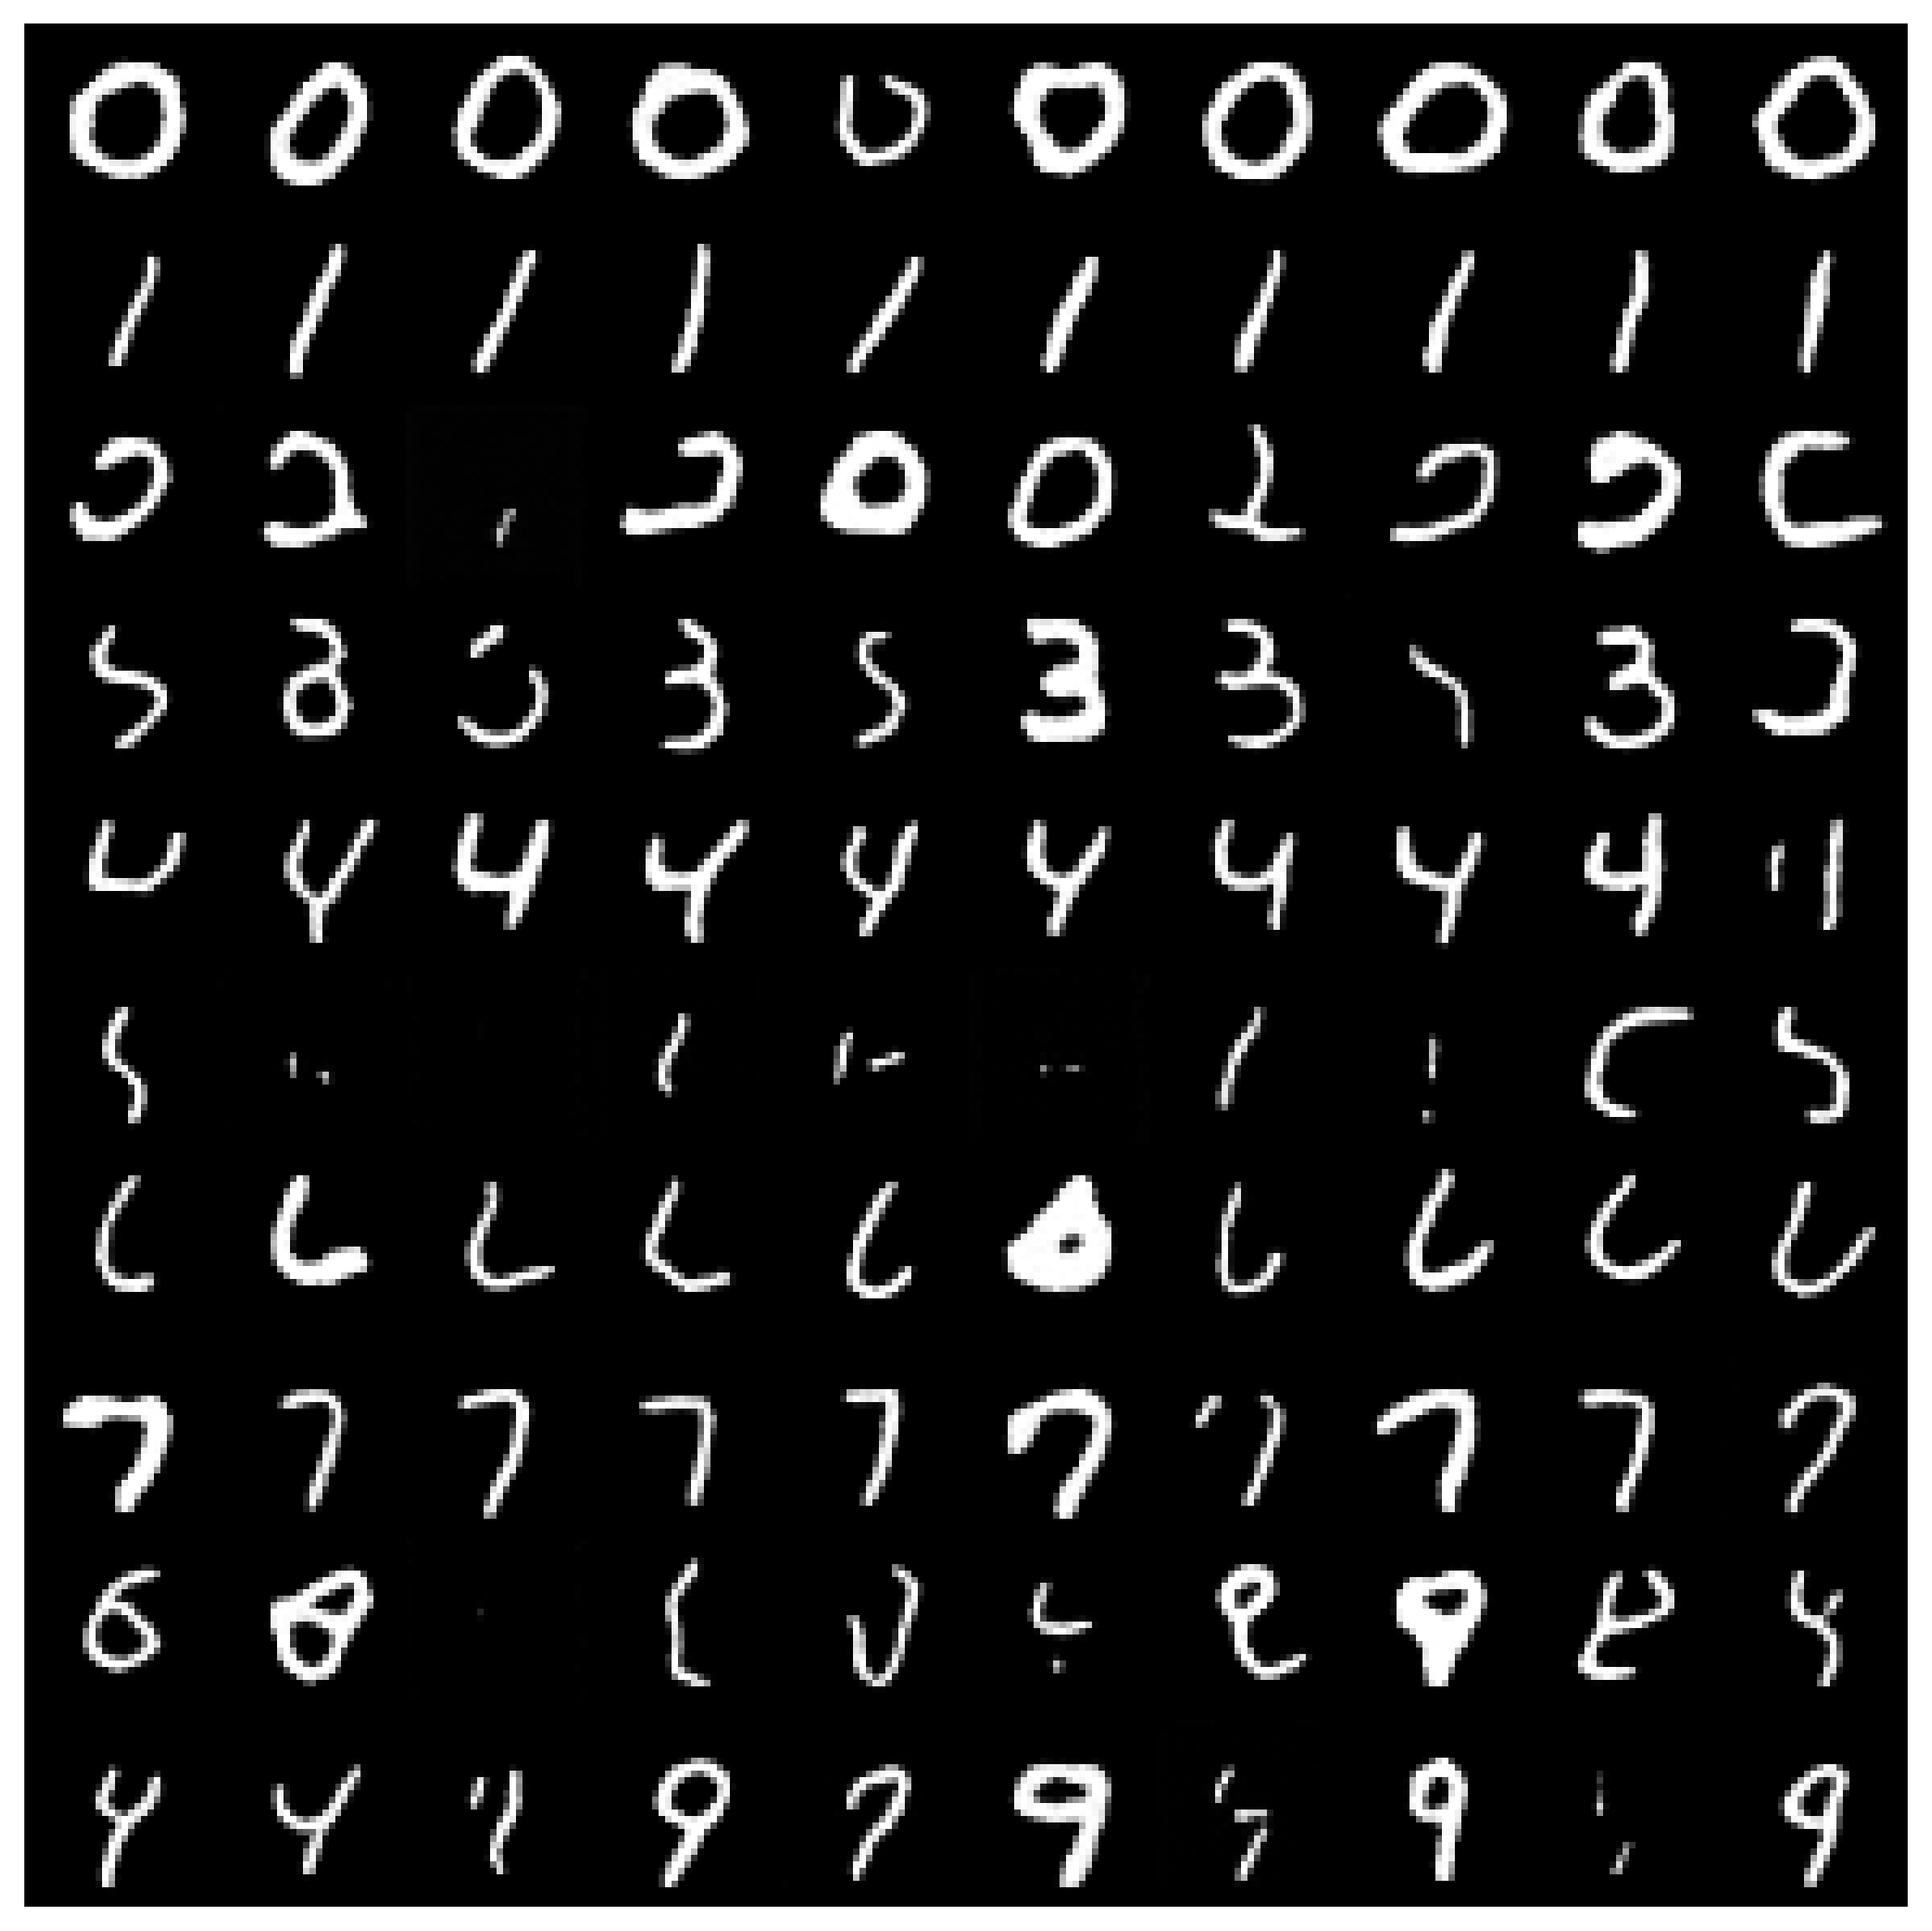

In [24]:
from rectified_flow.utils import plot_cifar_results

plot_cifar_results(x_1_euler)
plot_cifar_results(x_1_sde)

## Part 3 (10 pts): Classifier-Free Guidance (CFG) Scale Sweep

We sweep `cfg_scale` over {0.0, 0.5, 1.0, 2.0, 3.5, 5.0} to study the quality-diversity tradeoff.
- `cfg_scale=0`: purely unconditional samples
- `cfg_scale=1`: standard conditional samples (no guidance boost)
- Higher values: sharper class fidelity but reduced diversity

In [25]:
from rectified_flow.samplers import EulerSampler

ema_flow.apply_shadow()
model_inference = flow_model.eval()

# --- CFG sweep ---
cfg_scales = [0.0, 0.5, 1.0, 2.0, 3.5, 5.0]
cfg_results = {}

class_labels = torch.arange(10, device=device)
class_labels = class_labels.repeat_interleave(10, dim=0)
class_onehot = torch.nn.functional.one_hot(class_labels, num_classes=10).float()

# Fixed noise for consistent comparison
fixed_x0_cfg = torch.randn(100, *data_shape).to(device)

for scale in cfg_scales:
    def make_cfg_velocity(s):
        def velocity_with_cfg(x, t, class_labels=None):
            assert class_labels is not None
            v_uncond = model_inference(x, t, torch.zeros_like(class_labels))
            v_cond = model_inference(x, t, class_labels)
            return s * v_cond + (1.0 - s) * v_uncond
        return velocity_with_cfg

    rf_cfg = RectifiedFlow(
        data_shape=data_shape,
        velocity_field=make_cfg_velocity(scale),
        device=device,
    )
    sampler = EulerSampler(rf_cfg, num_steps=50, num_samples=100)
    x_1 = sampler.sample_loop(x_0=fixed_x0_cfg.clone(), class_labels=class_onehot).trajectories[-1]
    cfg_results[scale] = x_1.cpu()
    print(f"cfg_scale={scale:.1f} done")

cfg_scale=0.0 done
cfg_scale=0.5 done
cfg_scale=1.0 done
cfg_scale=2.0 done
cfg_scale=3.5 done
cfg_scale=5.0 done


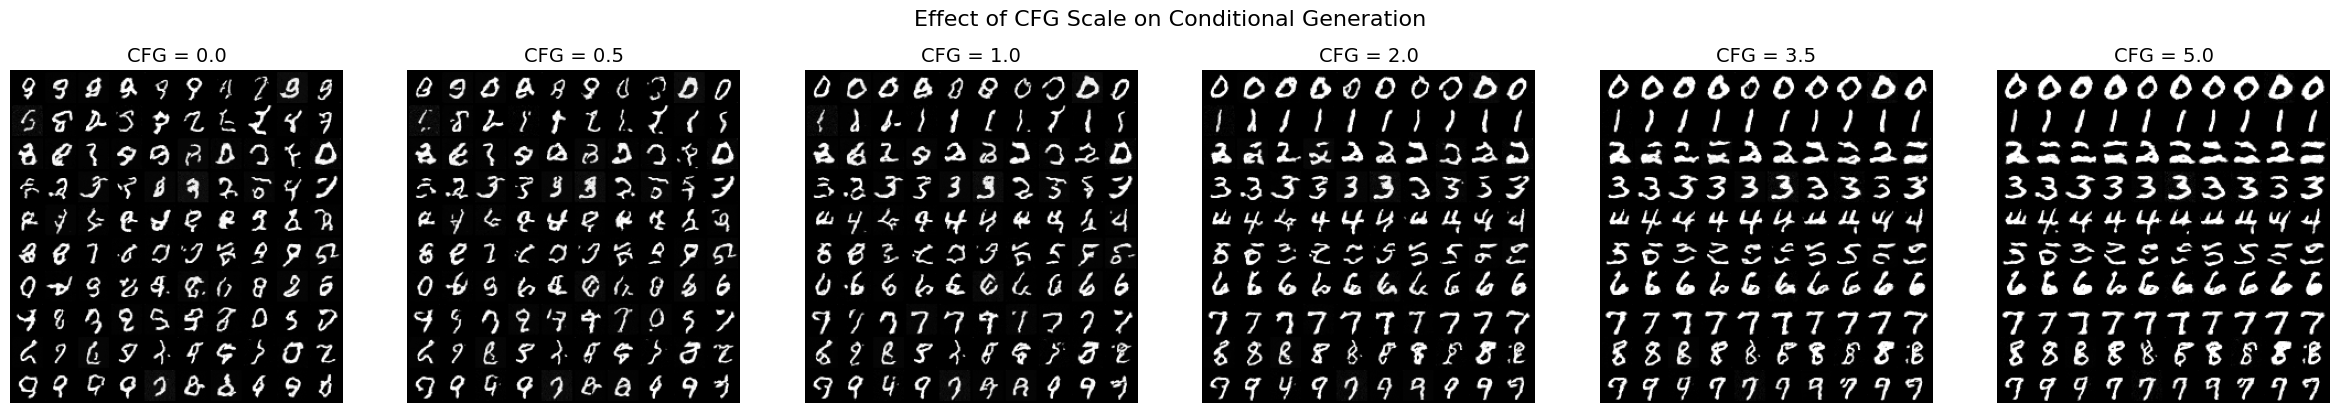

In [26]:
fig, axes = plt.subplots(1, len(cfg_scales), figsize=(4 * len(cfg_scales), 4))

for ax, scale in zip(axes, cfg_scales):
    samples = cfg_results[scale]
    grid = torchvision.utils.make_grid(samples[:100], nrow=10, normalize=True, value_range=(-1, 1))
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap='gray')
    ax.set_title(f"CFG = {scale:.1f}", fontsize=14)
    ax.axis('off')

fig.suptitle("Effect of CFG Scale on Conditional Generation", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Observations on CFG Scale

**`cfg_scale = 0.0`:** Purely unconditional — the model ignores class labels entirely. Generates diverse but class-incoherent samples.

**`cfg_scale = 0.5`:** Weak guidance — some class structure emerges but digits are often ambiguous or mixed.

**`cfg_scale = 1.0`:** Standard conditional generation (no guidance amplification). Digits are recognizable and class-consistent, with natural diversity.

**`cfg_scale = 2.0–3.5`:** Strong guidance — digits are sharper and more prototypical. Class fidelity improves significantly, but intra-class diversity begins to decrease (e.g., all "7"s start looking the same).

**`cfg_scale = 5.0`:** Very strong guidance — samples may become oversaturated or exhibit artifacts. The model overshoots toward the class-conditional mode, sacrificing diversity for extreme class specificity.

**Quality-Diversity Tradeoff:** CFG interpolates between the unconditional and conditional velocity fields. Higher scales amplify the conditional signal $v_\text{cfg} = s \cdot v_\text{cond} + (1-s) \cdot v_\text{uncond}$. This sharpens generation but collapses the mode toward a single prototype per class — a classic quality-diversity tradeoff analogous to the temperature parameter in language models.